# Validación del constructo de atención

Se usa el subconjunto descargado de NEMAR `nm000150` (BBBD, experimento 1): los mismos participantes ven el mismo vídeo en una sesión atenta y otra distraída contando hacia atrás de siete en siete. El conjunto contiene mirada y pupila, tiene licencia CC BY 4.0 y permite una comparación intra-sujeto. Fuente: https://www.nemar.org/dataset/nm000150

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from research.validation import load_nemar_recordings, paired_condition_tests, subject_disjoint_classifier

DATA = ROOT / 'data' / 'external' / 'nm000150_subset'
OUT = ROOT / 'docs' / 'research'
OUT.mkdir(parents=True, exist_ok=True)

In [2]:
recordings = load_nemar_recordings(DATA)
print({'recordings': len(recordings), 'subjects': recordings.subject.nunique(), 'conditions': recordings.condition.value_counts().to_dict()})
display(recordings.head())
assert recordings.subject.nunique() == 27
assert set(recordings.condition) == {'attentive', 'distracted'}

{'recordings': 51, 'subjects': 27, 'conditions': {'attentive': 27, 'distracted': 24}}


,subject,session,condition,samples,pupil_baseline,pupil_median,pupil_change_pct,pupil_cv_pct,gaze_dispersion_deg,gaze_step_deg,eyestim_score_mean
0,sub-02,ses-01,attentive,23662,61.822760,56.054591,-9.330171,5.652565,6.154995,0.009340,74.298954
1,sub-02,ses-02,distracted,23662,59.042543,59.707178,1.125688,4.765557,4.821447,0.009792,88.762405
2,sub-03,ses-01,attentive,23662,61.871439,55.517654,-10.269334,4.411307,6.739516,0.011677,75.598781
3,sub-03,ses-02,distracted,23662,52.523517,52.909159,0.734229,4.206502,9.638650,0.019894,86.762032
4,sub-04,ses-01,attentive,23662,63.063253,61.054718,-3.184952,5.063622,6.274741,0.013870,78.800071


## Comparaciones intra-sujeto

El score se reproduce con la misma calibración de 100 muestras y reglas de dilatación de EyeStim. EyeLink entrega área pupilar en unidades arbitrarias, por lo que se usa `sqrt(área)` como proxy dimensional de diámetro. Los ángulos de mirada se convierten a la escala nominal `[-1,1]` usando un campo fijo de ±20°. El resultado se interpreta como prueba de la regla heurística, no como reentrenamiento.

In [3]:
tests = paired_condition_tests(recordings)
classifier = subject_disjoint_classifier(recordings)
display(tests)
print('Clasificador exploratorio con validación leave-one-subject-out:', classifier)
score_test = tests.loc[tests.metric == 'eyestim_score_mean'].iloc[0]
assert score_test.attentive_minus_distracted < 0
assert score_test.wilcoxon_p < 0.05

,metric,paired_subjects,attentive_mean,distracted_mean,attentive_minus_distracted,paired_effect_dz,wilcoxon_p,expected_direction_rate
0,pupil_change_pct,24,-6.990254,-2.785668,-4.204586,-0.780035,0.000494,0.166667
1,pupil_cv_pct,24,5.860052,5.310719,0.549333,0.371269,0.064649,0.708333
2,gaze_dispersion_deg,24,6.381164,6.754127,-0.372963,-0.211507,0.359626,0.458333
3,gaze_step_deg,24,0.010716,0.012359,-0.001643,-0.295869,0.289667,0.458333
4,eyestim_score_mean,24,80.733947,86.616110,-5.882163,-0.838583,0.000430,0.208333


Clasificador exploratorio con validación leave-one-subject-out: {'recordings': 51.0, 'subjects': 27.0, 'accuracy': 0.6470588235294118, 'balanced_accuracy': 0.6412037037037037, 'roc_auc': 0.6959876543209876}


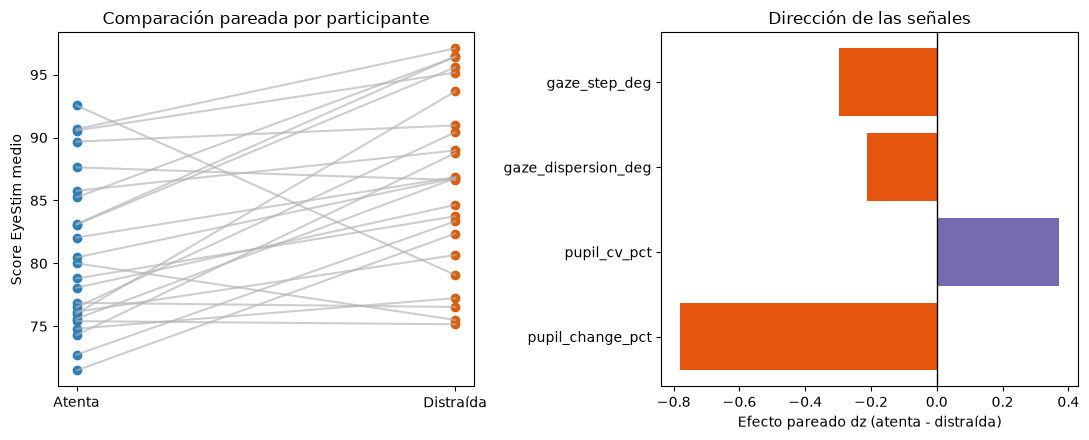

C:\Users\Eduar\AREA_PROGRAMCION\01_PROYECTOS\Eyestim\docs\research\attention_construct_validation.png


In [4]:
paired = recordings.pivot(index='subject', columns='condition', values='eyestim_score_mean').dropna()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for _, row in paired.iterrows(): axes[0].plot([0, 1], [row.attentive, row.distracted], color='0.7', alpha=.65)
axes[0].scatter([0] * len(paired), paired.attentive, color='#2c7fb8', label='Atenta')
axes[0].scatter([1] * len(paired), paired.distracted, color='#d95f0e', label='Distraída')
axes[0].set_xticks([0, 1], ['Atenta', 'Distraída']); axes[0].set_ylabel('Score EyeStim medio')
axes[0].set_title('Comparación pareada por participante')
metric_names = ['pupil_change_pct', 'pupil_cv_pct', 'gaze_dispersion_deg', 'gaze_step_deg']
effect = tests.set_index('metric').loc[metric_names, 'paired_effect_dz']
axes[1].barh(range(len(effect)), effect, color=['#756bb1' if x >= 0 else '#e6550d' for x in effect])
axes[1].set_yticks(range(len(effect)), effect.index); axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Efecto pareado dz (atenta - distraída)'); axes[1].set_title('Dirección de las señales')
fig.tight_layout(); figure_path = OUT / 'attention_construct_validation.png'; fig.savefig(figure_path, dpi=150); plt.show()
print(figure_path)

## Dictamen

La regla actual no mide atención específica a la pantalla: en este benchmark entrega un score significativamente mayor durante la condición distraída. Esto es coherente con que la pupila también responde al esfuerzo de la tarea secundaria, luminancia y activación autonómica. El clasificador exploratorio muestra que las señales contienen información, pero no valida la fórmula fija ni autoriza interpretar su salida como porcentaje de atención. Se necesita un modelo supervisado y calibrado con etiquetas de tarea/conducta, validación por participante y control de luminancia.